<div style="background-color:#D6EAF8; padding: 15px; border-radius: 10px; border: 1px solid #3498DB">

<h2 style="color:#154360;">🎯 Goal</h2>
<p>Analyze <strong>private school churn</strong> using Python. Data is fetched from a PostgreSQL database and processed for machine learning classification.</p>

<h3 style="color:#154360;">📦 Libraries Used</h3>
<ul>
    <li><code>psycopg</code> – connect to PostgreSQL</li>
    <li><code>pandas</code> – data manipulation</li>
    <li><code>json</code> – handle JSON data</li>
    <li><code>scikit-learn</code> – train/test split, scaling, classification</li>
    <li><code>matplotlib</code> & <code>seaborn</code> – visualization</li>
</ul>

<h3 style="color:#154360;">⚙️ Steps</h3>
<ol>
    <li>Fetch data from PostgreSQL</li>
    <li>Data cleaning and preprocessing</li>
    <li>Create dummy variables for categorical columns</li>
    <li>Scale numeric columns</li>
    <li>Train Random Forest classifier</li>
    <li>Evaluate model: classification report, confusion matrix, feature importance</li>
</ol>

</div>


In [1]:
# import sys
# sys.path.append('/Users/stepanromanov/PycharmProjects/omon_school')
import os
os.chdir('/Users/stepanromanov/PycharmProjects/omon_school')
import psycopg
import pandas as pd
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

with open('credentials/postgres.json', 'r') as f:
    creds = json.load(f)

conn_params = {
    'host': creds['host'],
    'port': creds['port'],
    'dbname': creds['database'],
    'user': creds['user'],
    'password': creds['password']
}

# --- SQL QUERY ---
query = """
WITH latest AS (
  SELECT 
      id,
      MAX(fetched_timestamp) AS max_ts
  FROM education_students_history__2526
  GROUP BY id
), 
students AS (
  SELECT h.*
  FROM education_students_history__2526 AS h
  JOIN latest l 
        ON h.id = l.id 
       AND h.fetched_timestamp = l.max_ts
)
SELECT
    students.filial,
    students.id AS student_id,
    students.balance,
    students.gender,
    students.status__name,
    CASE 
        WHEN students.birthday_timestamp < '1970-01-02' THEN NULL
        ELSE DATE_PART('year', AGE(CURRENT_DATE, students.birthday_timestamp))
    END AS age_years,

    -- Attendance percentage
    SUM(CASE WHEN attendances.state = 'attended' THEN 1 ELSE 0 END)::float /
    NULLIF(
        SUM(CASE WHEN attendances.state = 'attended' THEN 1 ELSE 0 END) +
        SUM(CASE WHEN attendances.state = 'not attended' THEN 1 ELSE 0 END) +
        SUM(CASE WHEN attendances.state = 'reasonable' THEN 1 ELSE 0 END) +
        SUM(CASE WHEN attendances.state NOT IN ('attended','not attended','reasonable') THEN 1 ELSE 0 END),
    0
    ) AS attended_percentage,

    -- Count marks
    COUNT(NULLIF(attendances.mark, 0)) AS all_marks,

    -- Average marks
    (SUM(attendances.mark)::float / NULLIF(COUNT(NULLIF(attendances.mark, 0)), 0))::numeric(10,2)
        AS average_mark

FROM students
LEFT JOIN education_attendances__2526 AS attendances 
       ON attendances.student_id = students.id
LEFT JOIN education_classes__2526 AS classes 
       ON students.class___id = classes.id
LEFT JOIN education_attendance_context__2526 AS att_context 
       ON attendances.lesson_id = att_context.id
LEFT JOIN education_journals__2526 AS journals 
       ON journals.subject_id = att_context.subject_id

GROUP BY 
    students.filial,
    students.id,
    students.balance,
    students.gender,
    students.status__name,
    birthday_timestamp;
"""

# --- EXECUTE QUERY ---
with psycopg.connect(**conn_params) as conn:
    df = pd.read_sql(query, conn)

df.head()


/var/folders/6g/gqlfr25n69d830mcyc6k4vfc0000gn/T/ipykernel_2261/3976249323.py:92: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,filial,student_id,balance,gender,status__name,age_years,attended_percentage,all_marks,average_mark
0,Omon School Gurlan,68889f1d81d12e5ed53520f2,0.0,male,inactive,NaN,NaN,0,NaN
1,Omon School Gurlan,68873b6681d12e5ed531b92b,0.0,male,active,NaN,0.985019,58,4.34
2,Omon School Urganch,6867568fa3447686a84e84be,-2900000.0,male,active,6.0,0.965385,20,4.70
3,Omon School Gurlan,689711bbe2d9868a2a4dd0a6,-10000.0,female,active,NaN,0.992308,31,4.29
4,Omon School Urganch,688cb4c15155d1fa398e8f82,-3575000.0,male,active,12.0,1.000000,76,4.63


In [2]:
df['status__name'].value_counts()

status__name
active      640
inactive    247
archive      46
new           1
Name: count, dtype: int64

In [3]:
# delete thos who haven't got even a single mark
df = df[df['all_marks'] > 0]
# delete all new
df = df[df['status__name'] != 'new']

In [4]:
# change all archived to inactive
df.loc[df['status__name'] == 'archive', 'status__name'] = '1'
df.loc[df['status__name'] == 'inactive', 'status__name'] = '1'
df.loc[df['status__name'] == 'active', 'status__name'] = '0'
df['status__name'] = df['status__name'].astype(int)
# check filtered df, 1 = churned, 0 = active
df['status__name'].value_counts()

status__name
0    626
1     84
Name: count, dtype: int64

In [5]:
# convert filial and gender into dummy/one-hot encoded columns
df = pd.get_dummies(df, columns=['filial', 'gender'], drop_first=True)

In [6]:
# Select numeric columns that have NaNs
num_cols_with_nan = ['age_years', 'attended_percentage', 'average_mark']

for col in num_cols_with_nan:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)  # assign back instead of inplace

In [7]:
# List of numeric columns to scale
num_cols = ['balance', 'age_years', 'attended_percentage', 'all_marks', 'average_mark']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [8]:
# normalized df
df.head()

,student_id,balance,status__name,age_years,attended_percentage,all_marks,average_mark,filial_Omon School Urganch,gender_male
1,68873b6681d12e5ed531b92b,0.402075,0,-0.016197,0.601245,0.339636,-0.633666,False,True
2,6867568fa3447686a84e84be,-0.854033,0,-2.145758,0.401305,-0.933408,0.316331,True,True
3,689711bbe2d9868a2a4dd0a6,0.397743,0,-0.016197,0.675471,-0.564895,-0.765610,False,False
4,688cb4c15155d1fa398e8f82,-1.146403,0,0.409716,0.753804,0.942656,0.131610,True,True
6,689edd1de2ab2a768cf1566a,-2.110141,0,1.261540,0.122281,0.808652,0.738553,True,False


In [9]:
# ------------------------------
# 1. Define features and target
# ------------------------------

# Target: 1 = churned, 0 = active,  df['status__name']

# Drop non-feature columns
X = df.drop(columns=['student_id', 'status__name'])
y = df['status__name']

# ------------------------------
# 2. Train/test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------
# 3. Train Random Forest Classifier
# ------------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

# ------------------------------
# 4. Predictions
# ------------------------------
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ------------------------------
# 5. Evaluation / Classification report
# ------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9084507042253521
ROC AUC: 0.952

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       125
           1       1.00      0.24      0.38        17

    accuracy                           0.91       142
   macro avg       0.95      0.62      0.67       142
weighted avg       0.92      0.91      0.88       142



<div style="background-color:#F0F8FF; padding: 15px; border-radius: 10px; border: 1px solid #3498DB">

<h2 style="color:#154360;">Classification Report Explanation</h2>

<p>A classification report provides a detailed performance summary of a classification model for each class. It includes <strong>precision</strong>, <strong>recall</strong>, <strong>F1-score</strong>, and <strong>support</strong>.</p>

<h3 style="color:#154360;">Classes in Our Churn Example</h3>
<ul>
    <li><strong>Class 0:</strong> Active students (not churned)</li>
    <li><strong>Class 1:</strong> Inactive students (churned)</li>
</ul>

<h3 style="color:#154360;">Metrics Explained</h3>
<ul>
    <li><strong>Precision:</strong> <code>TP / (TP + FP)</code> – Measures accuracy of positive predictions.<br>
        Example: Precision for class 1 tells you, “Of all students predicted as churned, what fraction actually churned?”<br>
        High precision → few false positives.
    </li>
    <li><strong>Recall (Sensitivity):</strong> <code>TP / (TP + FN)</code> – Measures ability to capture all actual positives.<br>
        Example: Recall for class 1 tells you, “Of all students who actually churned, how many did we correctly identify?”<br>
        High recall → few false negatives.
    </li>
    <li><strong>F1-score:</strong> Harmonic mean of precision and recall: <code>2 * (precision * recall) / (precision + recall)</code><br>
        Balances false positives and false negatives.<br>
        Useful for imbalanced datasets, such as churn prediction.
    </li>
    <li><strong>Support:</strong> Number of samples of each class in the dataset.</li>
</ul>

<h3 style="color:#154360;">Averages</h3>
<ul>
    <li><strong>Macro avg:</strong> Simple average across classes.</li>
    <li><strong>Weighted avg:</strong> Accounts for class imbalance.</li>
</ul>

<h3 style="color:#154360;">Why It Matters</h3>
<p>Shows model strengths and weaknesses per class and helps tune for high recall on churned students, which is critical for retention strategies.</p>

</div>


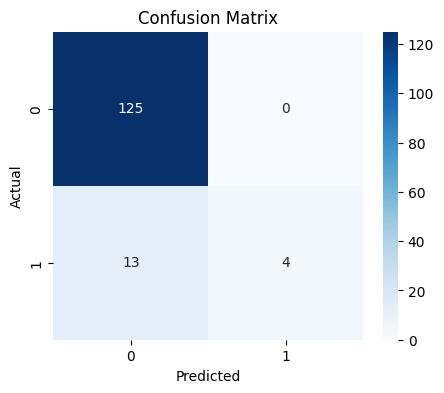

In [10]:
# ------------------------------
# 6. Confusion matrix
# ------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


<div style="background-color:#F0F8FF; padding: 15px; border-radius: 10px; border: 1px solid #3498DB">

<h2 style="color:#154360;">Confusion Matrix Explanation</h2>

<p>A <strong>confusion matrix</strong> is a table used to evaluate the performance of a classification model by comparing predicted labels against true labels.</p>

<h3 style="color:#154360;">Classes in Our Churn Example</h3>
<ul>
    <li><strong>0:</strong> Active student (not churned)</li>
    <li><strong>1:</strong> Inactive student (churned)</li>
</ul>

<h3 style="color:#154360;">Matrix Layout</h3>

<table style="border:1px solid #3498DB; border-collapse: collapse;">
<tr>
<th></th><th>Predicted 0</th><th>Predicted 1</th>
</tr>
<tr>
<td>Actual 0</td><td>True Negative (TN)</td><td>False Positive (FP)</td>
</tr>
<tr>
<td>Actual 1</td><td>False Negative (FN)</td><td>True Positive (TP)</td>
</tr>
</table>

<h3 style="color:#154360;">How to Read It</h3>
<ul>
    <li><strong>True Negative (TN):</strong> Correctly predicted active students.</li>
    <li><strong>True Positive (TP):</strong> Correctly predicted churned students.</li>
    <li><strong>False Positive (FP):</strong> Incorrectly predicted a student as churned when they are active.</li>
    <li><strong>False Negative (FN):</strong> Incorrectly predicted a student as active when they actually churned.</li>
</ul>

<h3 style="color:#154360;">Key Metrics From the Matrix</h3>
<ul>
    <li><strong>Accuracy:</strong> (TP + TN) / total — overall correctness</li>
    <li><strong>Precision:</strong> TP / (TP + FP) — of predicted churn, how many were correct</li>
    <li><strong>Recall (Sensitivity):</strong> TP / (TP + FN) — of actual churn, how many were caught</li>
    <li><strong>F1-score:</strong> Harmonic mean of precision and recall — balances false positives and false negatives</li>
</ul>

<h3 style="color:#154360;">Why It Matters</h3>
<p>The confusion matrix gives an immediate visual of where the model is making errors, which is critical for high-stakes churn prediction, where false negatives (missing churn) can be costly.</p>

</div>


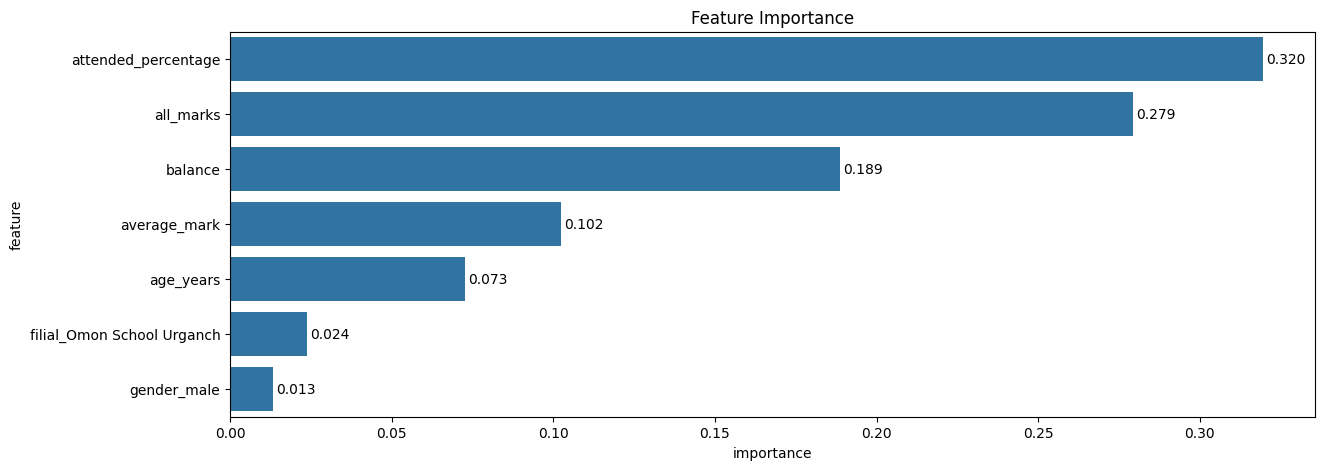

In [11]:
# ------------------------------
# 7. Feature importance with values
# ------------------------------
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(14,5))
ax = sns.barplot(x='importance', y='feature', data=importance)
plt.title("Feature Importance")

# Add value labels on each bar
for i, v in enumerate(importance['importance']):
    ax.text(v + 0.001, i, f"{v:.3f}", color='black', va='center')

plt.show()


<div style="background-color:#F0F8FF; padding: 15px; border-radius: 10px; border: 1px solid #3498DB">

<h2 style="color:#154360;">Feature Importance Explanation</h2>

<p><strong>Feature importance</strong> tells you how much each input variable contributes to the model’s predictions. In a Random Forest, importance is typically calculated by how much each feature decreases impurity (Gini or entropy) across all trees. Higher values mean the model relies on that feature more heavily.</p>

<h3 style="color:#154360;">Example Features in Churn Model</h3>
<ul>
    <li><strong>balance</strong> — student’s account balance</li>
    <li><strong>age_years</strong> — age of the student</li>
    <li><strong>attended_percentage</strong> — attendance ratio</li>
    <li><strong>all_marks / average_mark</strong> — academic performance</li>
    <li><strong>filial_Omon School Urganch, gender_male</strong> — dummy variables for branch and gender</li>
</ul>

<h3 style="color:#154360;">How to Interpret</h3>
<ul>
    <li>A feature with <strong>high importance</strong> significantly impacts predicting churn. Example: if <code>attended_percentage</code> is the highest, low attendance strongly correlates with students leaving.</li>
    <li>Features with <strong>low importance</strong> contribute little to the model and might be redundant or irrelevant.</li>
</ul>

<h3 style="color:#154360;">Practical Use</h3>
<ul>
    <li><strong>Target interventions:</strong> Focus on students with low attendance or poor marks if these are highly important.</li>
    <li><strong>Feature selection:</strong> Drop low-importance features to simplify the model.</li>
    <li><strong>Insights for stakeholders:</strong> Explains to teachers/administrators what drives churn, making decisions data-driven.</li>
</ul>

<p><strong>Note:</strong> Feature importance is not causal, but it provides actionable guidance and improves model interpretability, which is crucial for education analytics.</p>

</div>
